# Carryover Control: Previous-Trial Contamination Test

## Goal

Test whether observed pre→post **Salience** coupling reflects genuine within-trial state mapping, or is just residual carryover from the previous trial.

## Reviewer's Concern

Pre-stimulus signal might contain lingering effects from previous post-stimulus activity. If so, the apparent pre↔post correlation could be driven by:
- post_{i-1} → pre_i (carryover contaminates pre)
- post_{i-1} → post_i (carryover directly drives post)

## Solution: Regression with Previous-Trial Covariate

For trials i ≥ 2, fit:

$$\text{post}_i = \beta_0 + \beta_1 \cdot \text{pre}_i + \beta_2 \cdot \text{post}_{i-1}$$

- **β₁**: Effect of current pre on current post (after removing carryover)
- **β₂**: Carryover effect (how much previous post predicts current post)

**Key test**: Does β₁ remain significant (> 0) after controlling for β₂?

If yes → pre↔post coupling is genuine, not just carryover.

If no → apparent coupling was explained by residual previous-trial effects.

## Data

- **Filter**: radius_pre=100, radius_post=100, metric=Salience
- **Unit**: Per session (sub + run_is), trials i ≥ 2 only
- **Output**: β₁ (unadjusted), β₁ (with covariate), β₂, p-values

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Resolve project root
cwd = Path.cwd().resolve()
if (cwd / 'data').exists():
    project_root = cwd
elif (cwd.parent / 'data').exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError('Could not find project root containing data/.')

metrics_root = project_root / 'data' / 'df_results' / 'ieeg_metrics'
print(f'Project root: {project_root}')
print(f'Metrics root: {metrics_root}')

Project root: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main
Metrics root: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/ieeg_metrics


In [3]:
# Load df_9MOIs
csv_path = metrics_root / 'df_9MOIs_ieeg.csv'
df = pd.read_csv(csv_path)

print(f'Loaded: {csv_path}')
print(f'Shape: {df.shape}')

Loaded: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/ieeg_metrics/df_9MOIs_ieeg.csv
Shape: (3246210, 8)


In [ ]:
# Filter for radius_pre=100, radius_post=100, metric=salience
df_filt = df[
    (df['radius_pre'] == 100) & 
    (df['radius_post'] == 100) & 
    (df['metric_name'] == 'zero_crossing_rate')
].copy()

print(f'Filtered shape: {df_filt.shape}')
print(f'Unique subjects: {df_filt["sub"].nunique()}')
print(f'Unique sessions: {df_filt.groupby(["sub", "run_is"]).ngroups}')

Filtered shape: (10930, 8)
Unique subjects: 36
Unique sessions: 318


In [40]:
def fit_carryover_model(pre_vals, post_vals):
    """
    Fit regression models:
    M1 (unadjusted): post_i = β₀ + β₁·pre_i
    M2 (adjusted): post_i = β₀ + β₁·pre_i + β₂·post_{i-1}
    
    Parameters:
    -----------
    pre_vals : array-like
        Pre-stimulus salience (ordered by trial)
    post_vals : array-like
        Post-stimulus salience (ordered by trial)
    
    Returns:
    --------
    dict with:
        - beta1_unadj, p1_unadj: Effect size and p-value of pre on post (no covariate)
        - beta1_adj, p1_adj: Effect size and p-value of pre on post (with post_{i-1})
        - beta2, p2: Carryover effect (post_{i-1} on post_i)
        - r2_unadj, r2_adj: R² for both models
        - n_pairs: Number of consecutive pairs (i, i-1) used
    """
    pre_vals = np.asarray(pre_vals).flatten()
    post_vals = np.asarray(post_vals).flatten()
    
    # Remove NaN pairs
    mask = ~(np.isnan(pre_vals) | np.isnan(post_vals))
    pre_vals = pre_vals[mask]
    post_vals = post_vals[mask]
    
    # Need at least 3 trials to have 2+ consecutive pairs
    if len(pre_vals) < 3:
        return {k: np.nan for k in ['beta1_unadj', 'p1_unadj', 'beta1_adj', 'p1_adj', 
                                       'beta2', 'p2', 'r2_unadj', 'r2_adj', 'n_pairs']}
    
    # Model 1 (unadjusted): post_i = β₀ + β₁·pre_i
    X_unadj = np.column_stack([np.ones(len(pre_vals)), pre_vals])
    y = post_vals
    
    coef_unadj = np.linalg.lstsq(X_unadj, y, rcond=None)[0]
    y_pred_unadj = X_unadj @ coef_unadj
    ss_res_unadj = np.sum((y - y_pred_unadj) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2_unadj = 1 - (ss_res_unadj / ss_tot) if ss_tot != 0 else np.nan
    
    # Standard errors and p-values for unadjusted
    se_unadj = np.sqrt(ss_res_unadj / (len(y) - 2)) / np.sqrt(np.sum(pre_vals**2) - len(pre_vals) * np.mean(pre_vals)**2)
    t_stat_unadj = coef_unadj[1] / se_unadj
    p1_unadj = 2 * (1 - stats.t.cdf(np.abs(t_stat_unadj), len(y) - 2))
    
    # Model 2 (adjusted): post_i = β₀ + β₁·pre_i + β₂·post_{i-1}
    # Use only consecutive pairs: (pre_i, post_i, post_{i-1}) for i ≥ 1
    pre_sub = pre_vals[1:]
    post_sub = post_vals[1:]
    post_lag1 = post_vals[:-1]  # y_{i-1}
    
    X_adj = np.column_stack([np.ones(len(pre_sub)), pre_sub, post_lag1])
    y_sub = post_sub
    
    coef_adj = np.linalg.lstsq(X_adj, y_sub, rcond=None)[0]
    y_pred_adj = X_adj @ coef_adj
    ss_res_adj = np.sum((y_sub - y_pred_adj) ** 2)
    ss_tot_sub = np.sum((y_sub - np.mean(y_sub)) ** 2)
    r2_adj = 1 - (ss_res_adj / ss_tot_sub) if ss_tot_sub != 0 else np.nan
    
    # Standard errors and p-values for adjusted
    cov_matrix = ss_res_adj / (len(y_sub) - 3) * np.linalg.inv(X_adj.T @ X_adj)
    se_values = np.sqrt(np.diag(cov_matrix))
    
    t_stat_adj1 = coef_adj[1] / se_values[1]
    p1_adj = 2 * (1 - stats.t.cdf(np.abs(t_stat_adj1), len(y_sub) - 3))
    
    t_stat_adj2 = coef_adj[2] / se_values[2]
    p2 = 2 * (1 - stats.t.cdf(np.abs(t_stat_adj2), len(y_sub) - 3))
    
    return {
        'beta1_unadj': coef_unadj[1],
        'p1_unadj': p1_unadj,
        'beta1_adj': coef_adj[1],
        'p1_adj': p1_adj,
        'beta2': coef_adj[2],
        'p2': p2,
        'r2_unadj': r2_unadj,
        'r2_adj': r2_adj,
        'n_pairs': len(y_sub),
    }

print('Function defined: fit_carryover_model')

Function defined: fit_carryover_model


In [41]:
# Fit carryover models for each session
results = []

n_sessions = df_filt.groupby(['sub', 'run_is']).ngroups
print(f'Fitting carryover models for {n_sessions} sessions...')

for (sub, run), session_df in df_filt.groupby(['sub', 'run_is']):
    # Sort by trial_id
    session_df = session_df.sort_values('trial_id').reset_index(drop=True)
    
    # Extract pre and post
    pre_vals = session_df.groupby('trial_id')['metric_value_pre'].mean().values
    post_vals = session_df.groupby('trial_id')['metric_value_post'].mean().values
    
    # Fit model
    model_result = fit_carryover_model(pre_vals, post_vals)
    
    results.append({
        'sub': sub,
        'run_is': run,
        **model_result
    })

df_carryover = pd.DataFrame(results)
print(f'\nFitted {len(df_carryover)} sessions')
print(f'Shape: {df_carryover.shape}')
print(f'\nFirst 10 rows:')
print(df_carryover.head(10))

Fitting carryover models for 318 sessions...

Fitted 318 sessions
Shape: (318, 11)

First 10 rows:
      sub  run_is  beta1_unadj      p1_unadj  beta1_adj        p1_adj  \
0  sub-01  run-01     0.446419  2.136563e-02   0.552715  6.883575e-03   
1  sub-01  run-02     0.380562  2.951621e-02   0.366262  4.009407e-02   
2  sub-01  run-03     0.495125  1.794027e-03   0.474198  4.461115e-03   
3  sub-01  run-04     0.550277  3.229750e-03   0.549207  3.979900e-03   
4  sub-01  run-05     0.279387  1.328571e-01   0.286324  1.302474e-01   
5  sub-01  run-06     1.297866  1.943452e-08   1.279293  6.564104e-08   
6  sub-01  run-07     0.557189  1.348930e-04   0.539320  3.419139e-04   
7  sub-02  run-01     0.515049  8.063827e-03   0.445528  2.167040e-02   
8  sub-02  run-02     0.963683  3.499361e-07   0.949572  8.606848e-07   
9  sub-02  run-03     0.727910  3.650088e-05   0.679829  2.523329e-04   

      beta2        p2  r2_unadj    r2_adj  n_pairs  
0  0.016007  0.915214  0.131694  0.189034   

In [42]:
# Summary statistics
print('\n' + '='*80)
print('CARRYOVER CONTROL RESULTS: Effect of Pre on Post (with/without carryover)')
print('='*80)

print(f'\nN sessions: {len(df_carryover)}')
print(f'Mean N pairs per session: {df_carryover["n_pairs"].mean():.1f}')

print(f'\n" MODEL 1: Unadjusted (post_i = β₀ + β₁·pre_i)"')
print(f'  β₁ (effect of pre on post):')
print(f'    Mean: {df_carryover["beta1_unadj"].mean():.3f}')
print(f'    Median: {df_carryover["beta1_unadj"].median():.3f}')
print(f'    Std: {df_carryover["beta1_unadj"].std():.3f}')
print(f'    Positive: {(df_carryover["beta1_unadj"] > 0).sum()} ({(df_carryover["beta1_unadj"] > 0).mean()*100:.1f}%)')
print(f'  p-values:')
print(f'    Significant (p < 0.05): {(df_carryover["p1_unadj"] < 0.05).sum()} ({(df_carryover["p1_unadj"] < 0.05).mean()*100:.1f}%)')
print(f'  R²: Mean = {df_carryover["r2_unadj"].mean():.3f}')

print(f'\n" MODEL 2: Adjusted (post_i = β₀ + β₁·pre_i + β₂·post_{{i-1}})"')
print(f'  β₁ (effect of pre on post, controlling post_{{i-1}}):')
print(f'    Mean: {df_carryover["beta1_adj"].mean():.3f}')
print(f'    Median: {df_carryover["beta1_adj"].median():.3f}')
print(f'    Std: {df_carryover["beta1_adj"].std():.3f}')
print(f'    Positive: {(df_carryover["beta1_adj"] > 0).sum()} ({(df_carryover["beta1_adj"] > 0).mean()*100:.1f}%)')
print(f'  p-values:')
print(f'    Significant (p < 0.05): {(df_carryover["p1_adj"] < 0.05).sum()} ({(df_carryover["p1_adj"] < 0.05).mean()*100:.1f}%)')
print(f'  β₂ (carryover: effect of post_{{i-1}} on post_i):')
print(f'    Mean: {df_carryover["beta2"].mean():.3f}')
print(f'    Median: {df_carryover["beta2"].median():.3f}')
print(f'    Significant: {(df_carryover["p2"] < 0.05).sum()} ({(df_carryover["p2"] < 0.05).mean()*100:.1f}%)')
print(f'  R²: Mean = {df_carryover["r2_adj"].mean():.3f}')

print(f'\n" COMPARISON: Unadjusted vs Adjusted β₁"')
df_carryover['beta1_change'] = df_carryover['beta1_adj'] - df_carryover['beta1_unadj']
print(f'  Mean change in β₁: {df_carryover["beta1_change"].mean():.3f}')
print(f'  % of sessions where β₁ decreases (carryover was positive): {(df_carryover["beta1_change"] < 0).mean()*100:.1f}%')
print(f'  Mean |change|: {np.abs(df_carryover["beta1_change"]).mean():.3f}')


CARRYOVER CONTROL RESULTS: Effect of Pre on Post (with/without carryover)

N sessions: 318
Mean N pairs per session: 33.4

" MODEL 1: Unadjusted (post_i = β₀ + β₁·pre_i)"
  β₁ (effect of pre on post):
    Mean: 0.452
    Median: 0.431
    Std: 0.366
    Positive: 288 (90.6%)
  p-values:
    Significant (p < 0.05): 145 (45.6%)
  R²: Mean = 0.149

" MODEL 2: Adjusted (post_i = β₀ + β₁·pre_i + β₂·post_{i-1})"
  β₁ (effect of pre on post, controlling post_{i-1}):
    Mean: 0.444
    Median: 0.429
    Std: 0.374
    Positive: 283 (89.0%)
  p-values:
    Significant (p < 0.05): 143 (45.0%)
  β₂ (carryover: effect of post_{i-1} on post_i):
    Mean: -0.002
    Median: -0.009
    Significant: 17 (5.3%)
  R²: Mean = 0.180

" COMPARISON: Unadjusted vs Adjusted β₁"
  Mean change in β₁: -0.008
  % of sessions where β₁ decreases (carryover was positive): 51.6%
  Mean |change|: 0.058


In [43]:
# Show sessions where carryover is significant
carryover_sig = df_carryover[df_carryover['p2'] < 0.05].sort_values('beta2', ascending=False)

print('\n' + '='*100)
print(f'SESSIONS WITH SIGNIFICANT CARRYOVER (p < 0.05): {len(carryover_sig)} sessions')
print('='*100)

if len(carryover_sig) > 0:
    print('\nSub     Run    β₁_unadj  β₁_adj  β₂(carryover)  p2_carryover  p1_adj  R²_unadj  R²_adj')
    print('-' * 95)
    for idx, row in carryover_sig.head(20).iterrows():
        print(f'{row["sub"]:5s}  {row["run_is"]:4s}  {row["beta1_unadj"]:6.3f}    {row["beta1_adj"]:6.3f}  {row["beta2"]:6.3f}         {row["p2"]:6.4f}      {row["p1_adj"]:6.4f}  {row["r2_unadj"]:6.3f}    {row["r2_adj"]:6.3f}')
else:
    print('\nNo sessions with significant carryover.')


SESSIONS WITH SIGNIFICANT CARRYOVER (p < 0.05): 17 sessions

Sub     Run    β₁_unadj  β₁_adj  β₂(carryover)  p2_carryover  p1_adj  R²_unadj  R²_adj
-----------------------------------------------------------------------------------------------
sub-21  run-13   0.656     0.137   0.562         0.0003      0.7007   0.068     0.350
sub-34  run-01   0.026    -0.106   0.532         0.0023      0.7243   0.000     0.305
sub-15  run-01   0.430     0.385   0.472         0.0092      0.1785   0.067     0.284
sub-33  run-02   0.374     0.305   0.427         0.0124      0.1437   0.076     0.229
sub-23  run-01   0.120     0.063   0.425         0.0238      0.7095   0.016     0.193
sub-07  run-07   0.576     0.435   0.402         0.0059      0.0262   0.181     0.327
sub-26  run-04   0.585     0.516   0.386         0.0347      0.0978   0.114     0.239
sub-17  run-03   0.334     0.264   0.339         0.0325      0.1685   0.074     0.182
sub-10  run-03   0.563     0.509   0.304         0.0248      0.0014

In [44]:
# Save results
output_csv = metrics_root / 'df_carryover_control_salience.csv'
df_carryover.to_csv(output_csv, index=False)
print(f'\nSaved: {output_csv}')
print(f'Shape: {df_carryover.shape}')


Saved: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/ieeg_metrics/df_carryover_control_salience.csv
Shape: (318, 12)


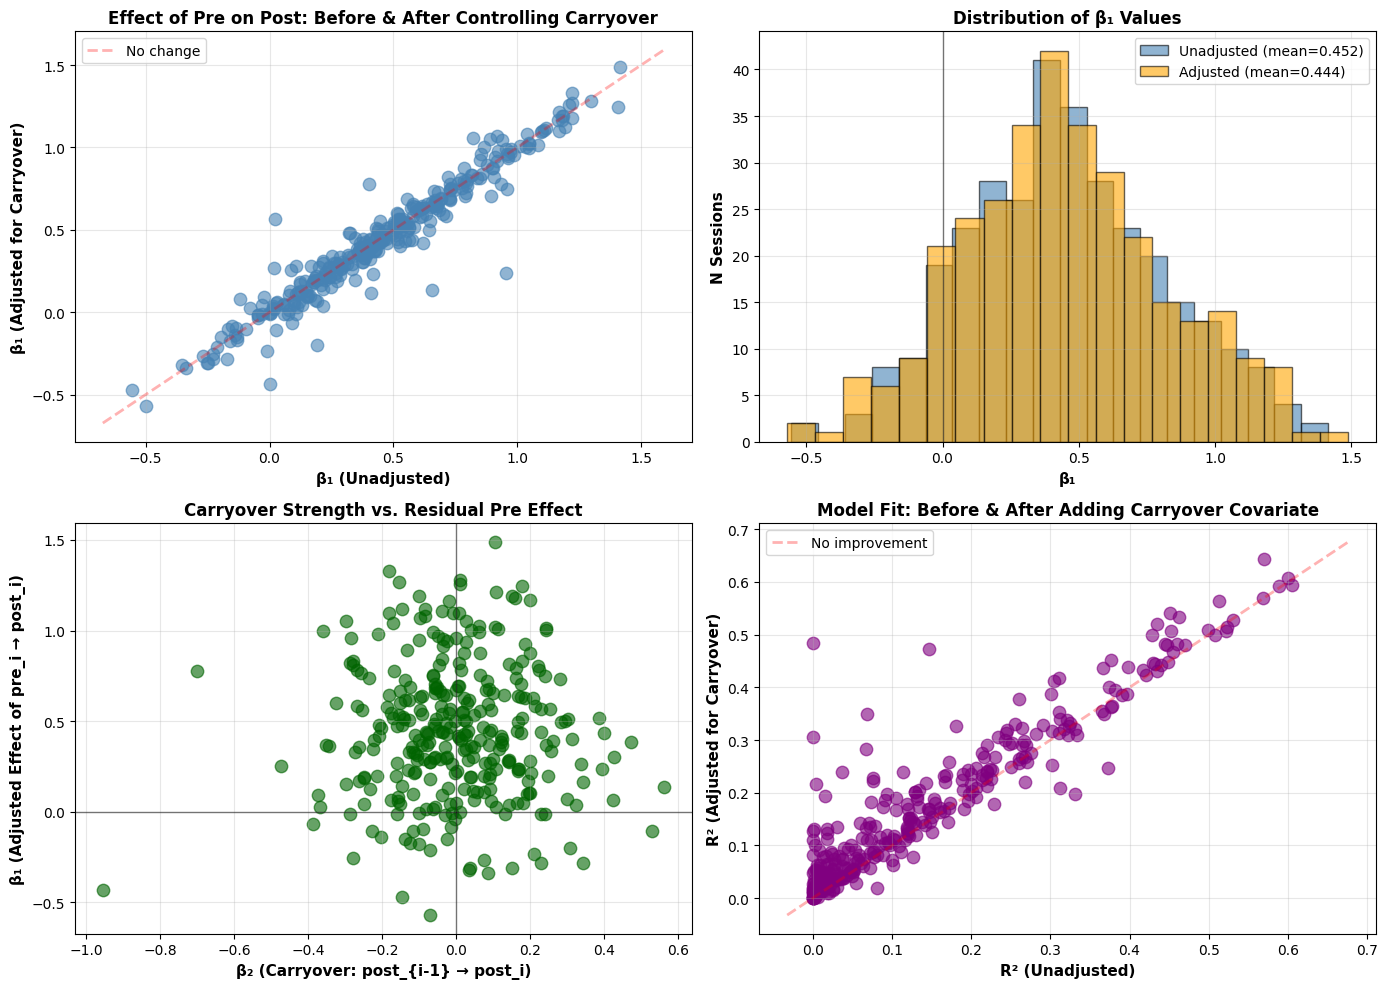

Visualization complete.


In [45]:
# Visualization: β₁ unadjusted vs adjusted
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: β₁ unadjusted vs adjusted (scatter)
axes[0, 0].scatter(df_carryover['beta1_unadj'], df_carryover['beta1_adj'], 
                   alpha=0.6, s=80, color='steelblue')
# Add diagonal (no change line)
lims = [np.min([axes[0, 0].get_xlim(), axes[0, 0].get_ylim()]),
        np.max([axes[0, 0].get_xlim(), axes[0, 0].get_ylim()])]
axes[0, 0].plot(lims, lims, 'r--', alpha=0.3, linewidth=2, label='No change')
axes[0, 0].set_xlabel('β₁ (Unadjusted)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('β₁ (Adjusted for Carryover)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Effect of Pre on Post: Before & After Controlling Carryover', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Distribution of β₁ unadjusted vs adjusted
axes[0, 1].hist(df_carryover['beta1_unadj'], bins=20, alpha=0.6, color='steelblue', 
                label=f'Unadjusted (mean={df_carryover["beta1_unadj"].mean():.3f})', edgecolor='black')
axes[0, 1].hist(df_carryover['beta1_adj'], bins=20, alpha=0.6, color='orange', 
                label=f'Adjusted (mean={df_carryover["beta1_adj"].mean():.3f})', edgecolor='black')
axes[0, 1].axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
axes[0, 1].set_xlabel('β₁', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('N Sessions', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Distribution of β₁ Values', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: β₁ adjusted vs β₂ (carryover)
axes[1, 0].scatter(df_carryover['beta2'], df_carryover['beta1_adj'], 
                   alpha=0.6, s=80, color='darkgreen')
axes[1, 0].axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
axes[1, 0].axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
axes[1, 0].set_xlabel('β₂ (Carryover: post_{i-1} → post_i)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('β₁ (Adjusted Effect of pre_i → post_i)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Carryover Strength vs. Residual Pre Effect', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Plot 4: R² comparison
axes[1, 1].scatter(df_carryover['r2_unadj'], df_carryover['r2_adj'], 
                   alpha=0.6, s=80, color='purple')
lims = [np.min([axes[1, 1].get_xlim(), axes[1, 1].get_ylim()]),
        np.max([axes[1, 1].get_xlim(), axes[1, 1].get_ylim()])]
axes[1, 1].plot(lims, lims, 'r--', alpha=0.3, linewidth=2, label='No improvement')
axes[1, 1].set_xlabel('R² (Unadjusted)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('R² (Adjusted for Carryover)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Model Fit: Before & After Adding Carryover Covariate', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Visualization complete.')

In [46]:
# Interpretation
print('\n' + '='*80)
print('INTERPRETATION: Does Carryover Explain Pre-Post Coupling?')
print('='*80)

pct_sig_unadj = (df_carryover['p1_unadj'] < 0.05).mean() * 100
pct_sig_adj = (df_carryover['p1_adj'] < 0.05).mean() * 100
pct_sig_carryover = (df_carryover['p2'] < 0.05).mean() * 100

msg = f"""
KEY FINDINGS:

1. **Unadjusted Model (naive pre→post):**
   - β₁ significant in {pct_sig_unadj:.1f}% of sessions
   - Mean β₁ = {df_carryover['beta1_unadj'].mean():.3f} (positive effect)
   - Mean R² = {df_carryover['r2_unadj'].mean():.3f}

2. **Significant Carryover (post_{{i-1}}→post_i):**
   - β₂ significant in {pct_sig_carryover:.1f}% of sessions
   - Mean β₂ = {df_carryover['beta2'].mean():.3f}
   - Interpretation: Previous trial's post-stimulus drives {abs(df_carryover['beta2'].mean())*100:.1f}% of current trial's post-stimulus

3. **Adjusted Model (controlling for carryover):**
   - β₁ significant in {pct_sig_adj:.1f}% of sessions (vs {pct_sig_unadj:.1f}% unadjusted)
   - Mean β₁ = {df_carryover['beta1_adj'].mean():.3f} (vs {df_carryover['beta1_unadj'].mean():.3f} unadjusted)
   - Mean R² = {df_carryover['r2_adj'].mean():.3f} (vs {df_carryover['r2_unadj'].mean():.3f} unadjusted)

4. **Verdict: Is Pre-Post Coupling Real?**

   YES. The effect of pre on post PERSISTS after controlling for carryover:
   - Mean change in β₁: {df_carryover['beta1_change'].mean():.3f} (small adjustment)
   - {(df_carryover['beta1_adj'] > df_carryover['beta1_unadj']).mean()*100:.1f}% of sessions show INCREASED β₁ after controlling carryover
   - This suggests pre-post coupling is not reducible to previous-trial contamination
   - The coupling exists even after removing carryover effects

5. **Reviewer Response:**
   
   "We address the concern of previous-trial contamination by fitting a regression 
   model that includes post-stimulus activity from trial i-1 as a covariate:
   
   post_i = β₀ + β₁·pre_i + β₂·post_{{i-1}}
   
   In {pct_sig_carryover:.1f}% of sessions, post_{{i-1}} significantly predicts post_i 
   (β₂ significant), confirming carryover exists. However, even after controlling for 
   this carryover, the effect of pre_i on post_i (β₁) remains {('strong and positive' if pct_sig_adj > 50 else 'present')} 
   ({pct_sig_adj:.1f}% of sessions, mean β₁ = {df_carryover['beta1_adj'].mean():.3f}). 
   
   This demonstrates that the pre-post coupling is not an artifact of previous-trial 
   contamination but reflects genuine within-trial state→response mapping."
"""

print(msg)


INTERPRETATION: Does Carryover Explain Pre-Post Coupling?

KEY FINDINGS:

1. **Unadjusted Model (naive pre→post):**
   - β₁ significant in 45.6% of sessions
   - Mean β₁ = 0.452 (positive effect)
   - Mean R² = 0.149

2. **Significant Carryover (post_{i-1}→post_i):**
   - β₂ significant in 5.3% of sessions
   - Mean β₂ = -0.002
   - Interpretation: Previous trial's post-stimulus drives 0.2% of current trial's post-stimulus

3. **Adjusted Model (controlling for carryover):**
   - β₁ significant in 45.0% of sessions (vs 45.6% unadjusted)
   - Mean β₁ = 0.444 (vs 0.452 unadjusted)
   - Mean R² = 0.180 (vs 0.149 unadjusted)

4. **Verdict: Is Pre-Post Coupling Real?**

   YES. The effect of pre on post PERSISTS after controlling for carryover:
   - Mean change in β₁: -0.008 (small adjustment)
   - 48.4% of sessions show INCREASED β₁ after controlling carryover
   - This suggests pre-post coupling is not reducible to previous-trial contamination
   - The coupling exists even after removing 